In [7]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

# ---------------------------------------------------
# Parametrisierte Count-Query
# ---------------------------------------------------
COUNT_QUERY = """
CALL {
  MATCH (n)
  RETURN
    count { (n) WHERE any(l IN labels(n) WHERE l IN $document_labels) } AS documents,
    count { (n) WHERE any(l IN labels(n) WHERE l IN $chunk_labels) }     AS chunks,
    count { (n) WHERE any(l IN labels(n) WHERE l IN $entity_labels) }    AS entities
}
CALL {
  MATCH ()-[r]-()
  RETURN count(r) AS total_relationships
}
RETURN documents, chunks, entities, total_relationships;
"""

def get_counts(database_name: str,
               document_labels: list[str],
               chunk_labels: list[str],
               entity_labels: list[str]) -> dict:
    with driver.session(database=database_name) as session:
        row = session.run(
            COUNT_QUERY,
            document_labels=document_labels,
            chunk_labels=chunk_labels,
            entity_labels=entity_labels,
        ).single()
    return {
        "database": database_name,
        "documents": row["documents"],
        "chunks": row["chunks"],
        "entities": row["entities"],
        "total_relationships": row["total_relationships"],
    }

# ---------------------------------------------------
# 3. Konfiguration pro Datenbank
# ---------------------------------------------------
configs = [
    # KG_Neo4j_Extractor_Version1
    {
        "db": "simplekg",
        "doc_labels": ["Document"],
        "chunk_labels": ["Chunk"],
        "entity_labels": ["__Entity__"],
    },
    # KG_Neo4j_Extractor_Version2
    {
        "db": "neo4j",
        "doc_labels": ["Document"],
        "chunk_labels": ["Chunk"],
        "entity_labels": ["__Entity__"],
    },
    # KG_LlamaIndex_Extractor
    {
        "db": "llmakg",
        "doc_labels": [],  # LlamaIndex hat keine Document-Knoten
        "chunk_labels": ["Chunk"],
        "entity_labels": ["__Entity__", "entity"],
    },
    # KG_Langchain_Extractor
    {
        "db": "llmagraphtrkg",
        # wenn du dort Document/Chunk-Labels hast, hier ergänzen
        "doc_labels": [],           # z.B. ["Document"]
        "chunk_labels": [],         # z.B. ["Chunk"]
        "entity_labels": ["__Entity__"],
    },
]

# Counts holen
results = [
    get_counts(
        c["db"],
        c["doc_labels"],
        c["chunk_labels"],
        c["entity_labels"],
    )
    for c in configs
]

driver.close()

# ---------------------------------------------------
# 4. DataFrame + Umbenennung
# ---------------------------------------------------
df = pd.DataFrame(results)

rename_map = {
    "simplekg": "KG_Neo4j_Extractor_Version1",
    "neo4j": "KG_Neo4j_Extractor_Version2",
    "llmakg": "KG_LlamaIndex_Extractor",
    "llmagraphtrkg": "KG_Langchain_Extractor",
}
df["database"] = df["database"].replace(rename_map)

df_long = df.melt(
    id_vars="database",
    value_vars=["documents", "chunks", "entities", "total_relationships"],
    var_name="type",
    value_name="count",
)

print(df)
print("\n--- df_long ---")
print(df_long)


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: CALL subquery without a variable scope clause is now deprecated. Use CALL () { ... }} {position: line: 2, column: 1, offset: 1} for query: '\nCALL {\n  MATCH (n)\n  RETURN\n    count { (n) WHERE any(l IN labels(n) WHERE l IN $document_labels) } AS documents,\n    count { (n) WHERE any(l IN labels(n) WHERE l IN $chunk_labels) }     AS chunks,\n    count { (n) WHERE any(l IN labels(n) WHERE l IN $entity_labels) }    AS entities\n}\nCALL {\n  MATCH ()-[r]-()\n  RETURN count(r) AS total_relationships\n}\nRETURN documents, chunks, entities, total_relationships;\n'
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and wil

                      database  documents  chunks  entities  \
0  KG_Neo4j_Extractor_Version1          0       0         1   
1  KG_Neo4j_Extractor_Version2          1       0         0   
2      KG_LlamaIndex_Extractor          0       1         0   
3       KG_Langchain_Extractor          0       0         0   

   total_relationships  
0                 3876  
1                 2504  
2                 8942  
3                 1814  

--- df_long ---
                       database                 type  count
0   KG_Neo4j_Extractor_Version1            documents      0
1   KG_Neo4j_Extractor_Version2            documents      1
2       KG_LlamaIndex_Extractor            documents      0
3        KG_Langchain_Extractor            documents      0
4   KG_Neo4j_Extractor_Version1               chunks      0
5   KG_Neo4j_Extractor_Version2               chunks      0
6       KG_LlamaIndex_Extractor               chunks      1
7        KG_Langchain_Extractor               chunks      0
8 

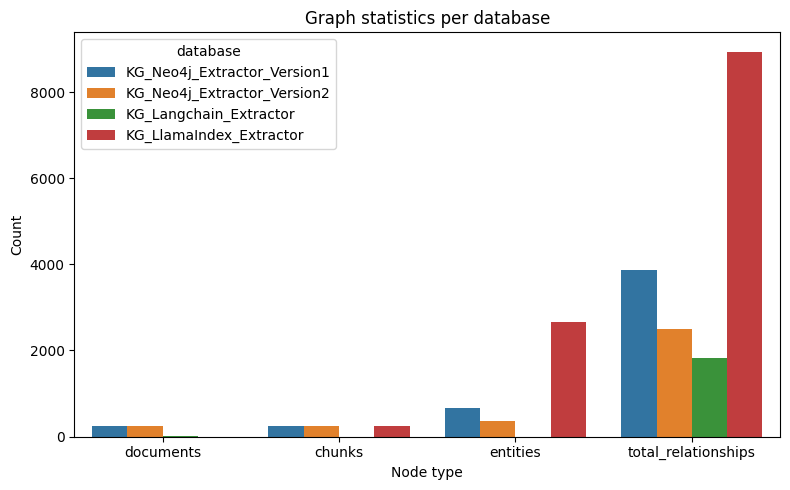

In [6]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_long,
    x="type",
    y="count",
    hue="database"
)
plt.title("Graph statistics per database")
plt.xlabel("Node type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
